In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import timm
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import transforms
from tqdm import tqdm

# Import custom dataset
from nodule_dataset import NoduleDataset

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

c:\Users\Edrill-LT\Documents\Projects\Python\Thoracic-Disease-Classifier-ResNet50\.torch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
# ============================================================
# CONFIGURATION
# ============================================================
csv_path = './dataset_nodule/jsrt_metadata.csv'
image_dir = './dataset_nodule/images/images'
batch_size = 16
num_epochs = 50
learning_rate = 1e-4
weight_decay = 1e-4
num_classes = 3
img_size = 224
num_workers = 4  # Start with 0 to debug - increase to 2-4 later


In [3]:
# ============================================================
# DATA PREPARATION
# ============================================================
print("\n" + "="*60)
print("PREPARING DATA")
print("="*60)

# Load CSV to get indices for stratified split
df = pd.read_csv(csv_path)
indices = np.arange(len(df))
labels = df['state'].map({'malignant': 0, 'benign': 1, 'non-nodule': 2}).values

# Stratified split: 70% train, 15% val, 15% test
train_idx, temp_idx, train_labels, temp_labels = train_test_split(
    indices, labels, test_size=0.3, random_state=42, stratify=labels
)

val_idx, test_idx, val_labels, test_labels = train_test_split(
    temp_idx, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

print(f"\nDataset splits:")
print(f"Train: {len(train_idx)} samples")
print(f"Val:   {len(val_idx)} samples")
print(f"Test:  {len(test_idx)} samples")

# Verify class distribution in each split
for split_name, split_labels in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    unique, counts = np.unique(split_labels, return_counts=True)
    print(f"\n{split_name} distribution:")
    for cls, cnt in zip(unique, counts):
        cls_name = ['malignant', 'benign', 'non-nodule'][cls]
        print(f"  {cls_name}: {cnt} ({cnt/len(split_labels)*100:.1f}%)")


PREPARING DATA

Dataset splits:
Train: 172 samples
Val:   37 samples
Test:  38 samples

Train distribution:
  malignant: 70 (40.7%)
  benign: 37 (21.5%)
  non-nodule: 65 (37.8%)

Val distribution:
  malignant: 15 (40.5%)
  benign: 8 (21.6%)
  non-nodule: 14 (37.8%)

Test distribution:
  malignant: 15 (39.5%)
  benign: 9 (23.7%)
  non-nodule: 14 (36.8%)


In [4]:
# ============================================================
# DATA TRANSFORMS
# ============================================================
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                       std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                       std=[0.229, 0.224, 0.225])
])


In [5]:
# ============================================================
# CREATE DATASETS AND DATALOADERS
# ============================================================
# Create full datasets
train_dataset_full = NoduleDataset(
    csv_path, 
    image_dir, 
    transform=train_transform
)

val_dataset_full = NoduleDataset(
    csv_path, 
    image_dir, 
    transform=val_test_transform
)

test_dataset_full = NoduleDataset(
    csv_path, 
    image_dir, 
    transform=val_test_transform
)

# Create subsets
train_dataset = Subset(train_dataset_full, train_idx)
val_dataset = Subset(val_dataset_full, val_idx)
test_dataset = Subset(test_dataset_full, test_idx)

# Calculate class weights for weighted loss
class_counts = train_dataset_full.get_class_counts()
total_train = len(train_idx)
class_weights = torch.tensor([
    total_train / class_counts['malignant'],
    total_train / class_counts['benign'],
    total_train / class_counts['non-nodule']
], dtype=torch.float).to(device)

print(f"\nClass weights: {class_weights.cpu().numpy()}")

# Create dataloaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)


Class weights: [1.72      3.1851852 1.8494624]


In [6]:
# ============================================================
# MODEL CREATION
# ============================================================
print("\n" + "="*60)
print("CREATING MODEL")
print("="*60)

# Create ResNet50 with FPN using timm
model = timm.create_model(
    'resnet50',
    pretrained=True,
    features_only=True,  # Get feature maps for FPN
    num_classes=0  # Remove classification head
)

# Get feature dimensions from ResNet50
dummy_input = torch.randn(1, 3, img_size, img_size)
with torch.no_grad():
    feature_maps = model(dummy_input)
    feature_dims = [f.shape[1] for f in feature_maps]

print(f"Feature map dimensions: {feature_dims}")

# Simple FPN implementation
class SimpleFPN(nn.Module):
    def __init__(self, in_channels_list, out_channels=256):
        super(SimpleFPN, self).__init__()
        
        # Lateral connections
        self.lateral_convs = nn.ModuleList([
            nn.Conv2d(in_ch, out_channels, kernel_size=1)
            for in_ch in in_channels_list
        ])
        
        # Output convolutions
        self.output_convs = nn.ModuleList([
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
            for _ in in_channels_list
        ])
        
    def forward(self, feature_maps):
        # Process from top to bottom
        laterals = [conv(f) for conv, f in zip(self.lateral_convs, feature_maps)]
        
        # Top-down pathway
        for i in range(len(laterals) - 1, 0, -1):
            laterals[i-1] += nn.functional.interpolate(
                laterals[i], 
                size=laterals[i-1].shape[-2:], 
                mode='nearest'
            )
        
        # Apply output convolutions
        outputs = [conv(lateral) for conv, lateral in zip(self.output_convs, laterals)]
        return outputs

# Complete model with classifier
class ResNetFPNClassifier(nn.Module):
    def __init__(self, backbone, fpn, num_classes=3):
        super(ResNetFPNClassifier, self).__init__()
        self.backbone = backbone
        self.fpn = fpn
        
        # Global average pooling and classifier
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(256 * 5, 512),  # 5 feature maps from FPN
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        # Extract features
        feature_maps = self.backbone(x)
        
        # Apply FPN
        fpn_outputs = self.fpn(feature_maps)
        
        # Pool and concatenate
        pooled = [self.gap(f).flatten(1) for f in fpn_outputs]
        merged = torch.cat(pooled, dim=1)
        
        # Classify
        output = self.classifier(merged)
        return output

# Create FPN and full model
fpn = SimpleFPN(feature_dims, out_channels=256)
full_model = ResNetFPNClassifier(model, fpn, num_classes=num_classes)
full_model = full_model.to(device)

print(f"\nModel created successfully!")
print(f"Total parameters: {sum(p.numel() for p in full_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in full_model.parameters() if p.requires_grad):,}")



CREATING MODEL
Feature map dimensions: [64, 256, 512, 1024, 2048]

Model created successfully!
Total parameters: 28,116,547
Trainable parameters: 28,116,547


In [7]:
# ============================================================
# LOSS AND OPTIMIZER
# ============================================================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(
    full_model.parameters(), 
    lr=learning_rate,
    weight_decay=weight_decay
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

In [8]:
# ============================================================
# TRAINING FUNCTIONS
# ============================================================
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(dataloader, desc='Training')
    for batch_idx, (images, labels) in enumerate(pbar):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)  # More efficient
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Update progress bar less frequently
        if batch_idx % 1 == 0:
            pbar.set_postfix({
                'loss': f'{running_loss/total:.4f}',
                'acc': f'{100.*correct/total:.2f}%'
            })
    
    return running_loss / total, 100. * correct / total

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validation'):
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return running_loss / total, 100. * correct / total, all_preds, all_labels


In [9]:
# ============================================================
# TRAINING LOOP
# ============================================================
print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)

best_val_acc = 0.0
train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 60)
    
    # Train
    train_loss, train_acc = train_epoch(full_model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate
    val_loss, val_acc, _, _ = validate(full_model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # Update learning rate
    scheduler.step()
    
    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': full_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, 'best_model.pth')
        print(f"✓ Best model saved! (Val Acc: {val_acc:.2f}%)")


STARTING TRAINING

Epoch 1/50
------------------------------------------------------------


Validation: 100%|██████████| 3/3 [00:05<00:00,  1.82s/it]



Train Loss: 1.3021 | Train Acc: 34.30%
Val Loss: 1.2004 | Val Acc: 37.84%
LR: 0.000100
✓ Best model saved! (Val Acc: 37.84%)

Epoch 2/50
------------------------------------------------------------


Validation: 100%|██████████| 3/3 [00:06<00:00,  2.10s/it]



Train Loss: 1.2403 | Train Acc: 43.02%
Val Loss: 1.2087 | Val Acc: 21.62%
LR: 0.000100

Epoch 3/50
------------------------------------------------------------


...


Train Loss: 0.6313 | Train Acc: 75.00%
Val Loss: 1.4105 | Val Acc: 54.05%
LR: 0.000000
✓ Best model saved! (Val Acc: 54.05%)

Epoch 49/50
------------------------------------------------------------


Validation: 100%|██████████| 3/3 [00:06<00:00,  2.09s/it]



Train Loss: 0.6860 | Train Acc: 69.77%
Val Loss: 1.4143 | Val Acc: 48.65%
LR: 0.000000

Epoch 50/50
------------------------------------------------------------


Validation: 100%|██████████| 3/3 [00:06<00:00,  2.31s/it]


Train Loss: 0.7057 | Train Acc: 68.02%
Val Loss: 1.4436 | Val Acc: 48.65%
LR: 0.000000



TRAINING COMPLETE


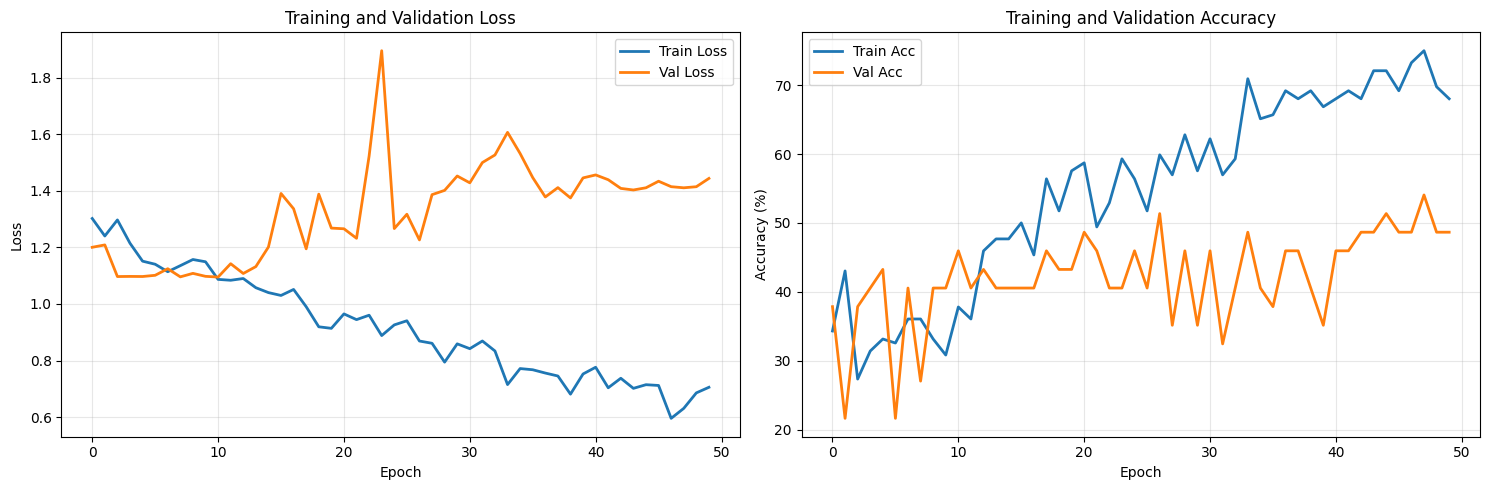

In [10]:
# ============================================================
# PLOT TRAINING CURVES
# ============================================================
print("\n" + "="*60)
print("TRAINING COMPLETE")
print("="*60)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
ax1.plot(train_losses, label='Train Loss', linewidth=2)
ax1.plot(val_losses, label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(train_accs, label='Train Acc', linewidth=2)
ax2.plot(val_accs, label='Val Acc', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


EVALUATING ON TEST SET


Validation: 100%|██████████| 3/3 [00:07<00:00,  2.53s/it]



Test Loss: 1.6011
Test Accuracy: 28.95%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   malignant     0.3333    0.4667    0.3889        15
      benign     0.0000    0.0000    0.0000         9
  non-nodule     0.3077    0.2857    0.2963        14

    accuracy                         0.2895        38
   macro avg     0.2137    0.2508    0.2284        38
weighted avg     0.2449    0.2895    0.2627        38



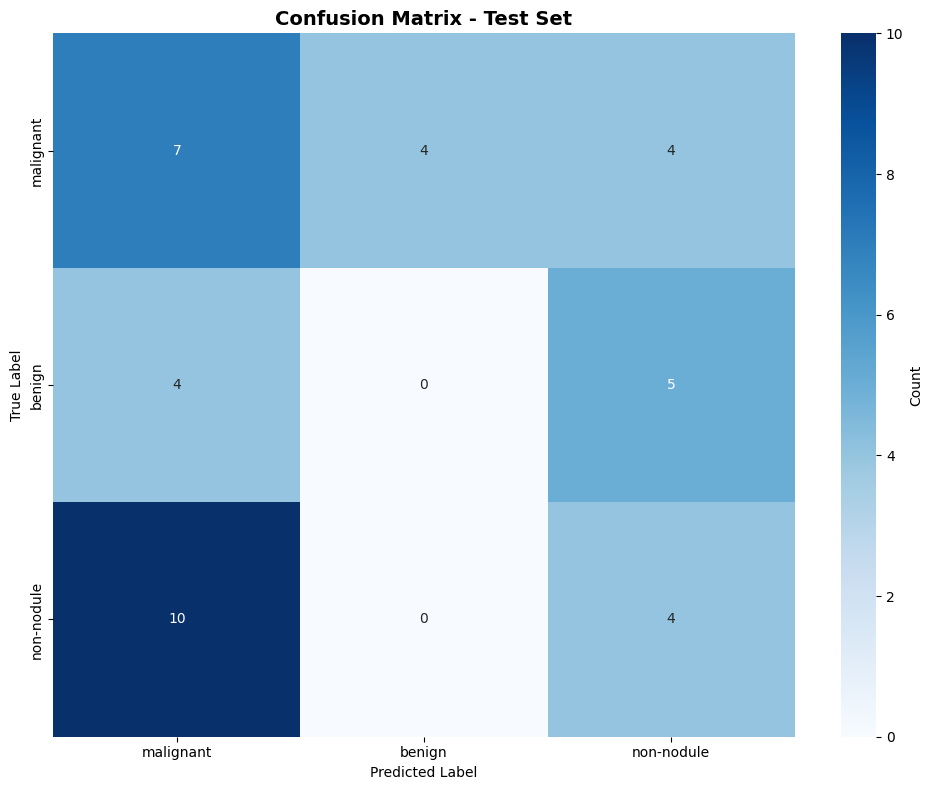


TRAINING AND EVALUATION COMPLETE!
Best validation accuracy: 54.05%
Test accuracy: 28.95%

Saved files:
  - best_model.pth
  - training_curves.png
  - confusion_matrix.png


In [11]:
# ============================================================
# EVALUATE ON TEST SET
# ============================================================
print("\n" + "="*60)
print("EVALUATING ON TEST SET")
print("="*60)

# Load best model
checkpoint = torch.load('best_model.pth')
full_model.load_state_dict(checkpoint['model_state_dict'])

# Evaluate
test_loss, test_acc, test_preds, test_labels = validate(full_model, test_loader, criterion, device)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

# Classification report
class_names = ['malignant', 'benign', 'non-nodule']
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(test_labels, test_preds, target_names=class_names, digits=4))

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("TRAINING AND EVALUATION COMPLETE!")
print("="*60)
print(f"Best validation accuracy: {best_val_acc:.2f}%")
print(f"Test accuracy: {test_acc:.2f}%")
print("\nSaved files:")
print("  - best_model.pth")
print("  - training_curves.png")
print("  - confusion_matrix.png")